# Lab 3 Data Processing

### 1. Import the libraries

In [272]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the dataset

In [273]:

## notes for sir
# Hi sir, you can either import from kagglehub or use the .read_csv() function

"""
Import from kagglehub
"""
import kagglehub

# Download latest version
path = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")
df = pd.read_csv(f"{path}/diabetes_prediction_dataset.csv")
print("Path to dataset files:", path)
"""
Use .read_csv() function
"""
# df = pd.read_csv('./diabetes_prediction_dataset.csv')

Path to dataset files: /Users/cxnner05/.cache/kagglehub/datasets/iammustafatz/diabetes-prediction-dataset/versions/1


'\nUse .read_csv() function\n'

Read the data, get information about the dataset

In [274]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


All of the code are non null, and seems to have the correct data type. Try to read the first parts of the data

In [275]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


Try doing unique values for each column to see if there are any anomalies

In [276]:
for column in df.columns:
    unique_values = df[column].unique()
    print(f"Column: {column}")
    print(f"Unique values ({len(unique_values)}): {unique_values}\n")

Column: gender
Unique values (3): ['Female' 'Male' 'Other']

Column: age
Unique values (102): [80.   54.   28.   36.   76.   20.   44.   79.   42.   32.   53.   78.
 67.   15.   37.   40.    5.   69.   72.    4.   30.   45.   43.   50.
 41.   26.   34.   73.   77.   66.   29.   60.   38.    3.   57.   74.
 19.   46.   21.   59.   27.   13.   56.    2.    7.   11.    6.   55.
  9.   62.   47.   12.   68.   75.   22.   58.   18.   24.   17.   25.
  0.08 33.   16.   61.   31.    8.   49.   39.   65.   14.   70.    0.56
 48.   51.   71.    0.88 64.   63.   52.    0.16 10.   35.   23.    0.64
  1.16  1.64  0.72  1.88  1.32  0.8   1.24  1.    1.8   0.48  1.56  1.08
  0.24  1.4   0.4   0.32  1.72  1.48]

Column: hypertension
Unique values (2): [0 1]

Column: heart_disease
Unique values (2): [1 0]

Column: smoking_history
Unique values (6): ['never' 'No Info' 'current' 'former' 'ever' 'not current']

Column: bmi
Unique values (4247): [25.19 27.32 23.45 ... 59.42 44.39 60.52]

Column: HbA1c_lev

Based on the data, we have small set of unique values for some columns like hypertension, heart_disease, smoking_history, and diabetes. We can check the distribution of these values using value_counts() method. This will help us understand the frequency of each unique value in these columns.

In [277]:
for column in ['hypertension', 'heart_disease', 'smoking_history', 'diabetes']:
    value_counts = df[column].value_counts()
    print(f"Value counts for column:'{column}':")
    print(value_counts)
    print()

Value counts for column:'hypertension':
hypertension
0    92515
1     7485
Name: count, dtype: int64

Value counts for column:'heart_disease':
heart_disease
0    96058
1     3942
Name: count, dtype: int64

Value counts for column:'smoking_history':
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

Value counts for column:'diabetes':
diabetes
0    91500
1     8500
Name: count, dtype: int64



## 3. Cleaning the Data Set

We can start by cleaning up the smoking_history column, grouping unknown or no values together.

We can start with the smoking history

In [278]:
df['smoking_history'].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

In [279]:
# We can create a new columns smoking_status to group unknown and never smoked together
# 
clean_smoking_history_map = {
    "never": "Never",
    "No Info": "Unknown",
    "current": "Current",
    "former": "Past",
    "ever": "Past",
    "not current": "Past"
}

In [280]:
# Apply the function to create a new column
df['smoking_history'] = df['smoking_history'].map(clean_smoking_history_map).fillna('never')

Drop duplicate columns

In [281]:
df.duplicated().sum()

np.int64(4032)

In [282]:
df.drop_duplicates(inplace=True)

In [283]:
df.duplicated().sum()

np.int64(0)

In [284]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95968 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               95968 non-null  object 
 1   age                  95968 non-null  float64
 2   hypertension         95968 non-null  int64  
 3   heart_disease        95968 non-null  int64  
 4   smoking_history      95968 non-null  object 
 5   bmi                  95968 non-null  float64
 6   HbA1c_level          95968 non-null  float64
 7   blood_glucose_level  95968 non-null  int64  
 8   diabetes             95968 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 7.3+ MB


Handle Null columns

In [285]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Checking the Columns

In [286]:
non_numerical_cols = df.select_dtypes(exclude=['number']).columns
non_numerical_cols

Index(['gender', 'smoking_history'], dtype='object')

In [287]:
print('Unique values in non-numerical columns:')

# Genre
print(non_numerical_cols[0], ':')
print('-----------------------------------')
print(df[non_numerical_cols[0]].unique())
print('-----------------------------------')

# Smoking History
print('\n')
print(non_numerical_cols[1], '(original data)', ':')
print('-----------------------------------')
print(df[non_numerical_cols[1]].unique())
print('-----------------------------------')

Unique values in non-numerical columns:
gender :
-----------------------------------
['Female' 'Male' 'Other']
-----------------------------------


smoking_history (original data) :
-----------------------------------
['Never' 'Unknown' 'Current' 'Past']
-----------------------------------


## 4. Visualize the data

Group the age group and the risk score to see the distribution of risk score across different age groups

### Distribution of data by Gender

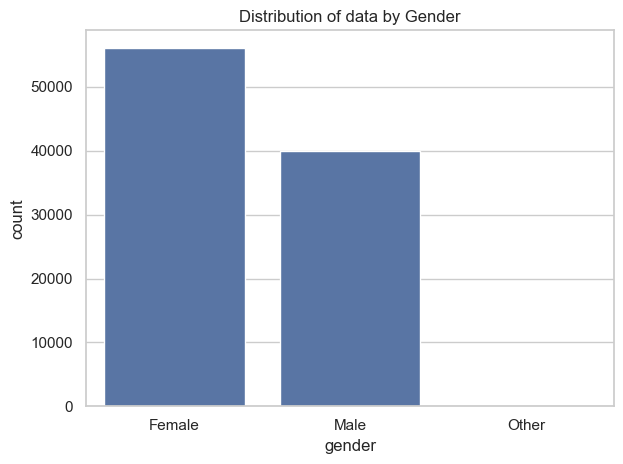

In [288]:
sns.countplot(data=df, x=df["gender"])
plt.title('Distribution of data by Gender')

plt.tight_layout()
plt.show()

### Distribution of Smoking History

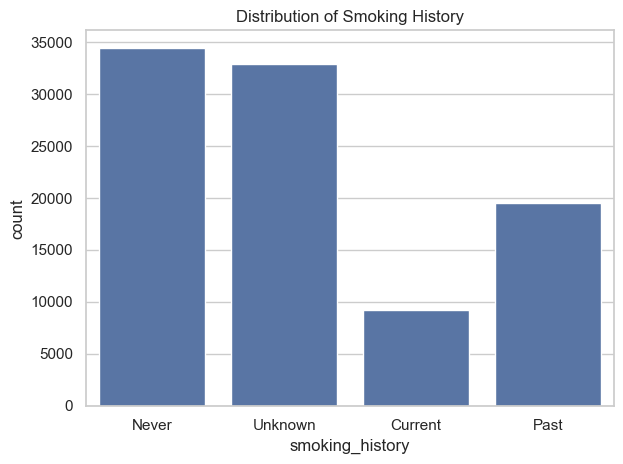

In [289]:
sns.countplot(data=df, x=df["smoking_history"])
plt.title('Distribution of Smoking History')

plt.tight_layout()
plt.show()

Next up is checking for skewness in the data.

y = Count
x = feature / numerical columns

In [290]:
numerical_cols = df.select_dtypes(include=['number']).columns
numerical_cols

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'diabetes'],
      dtype='object')

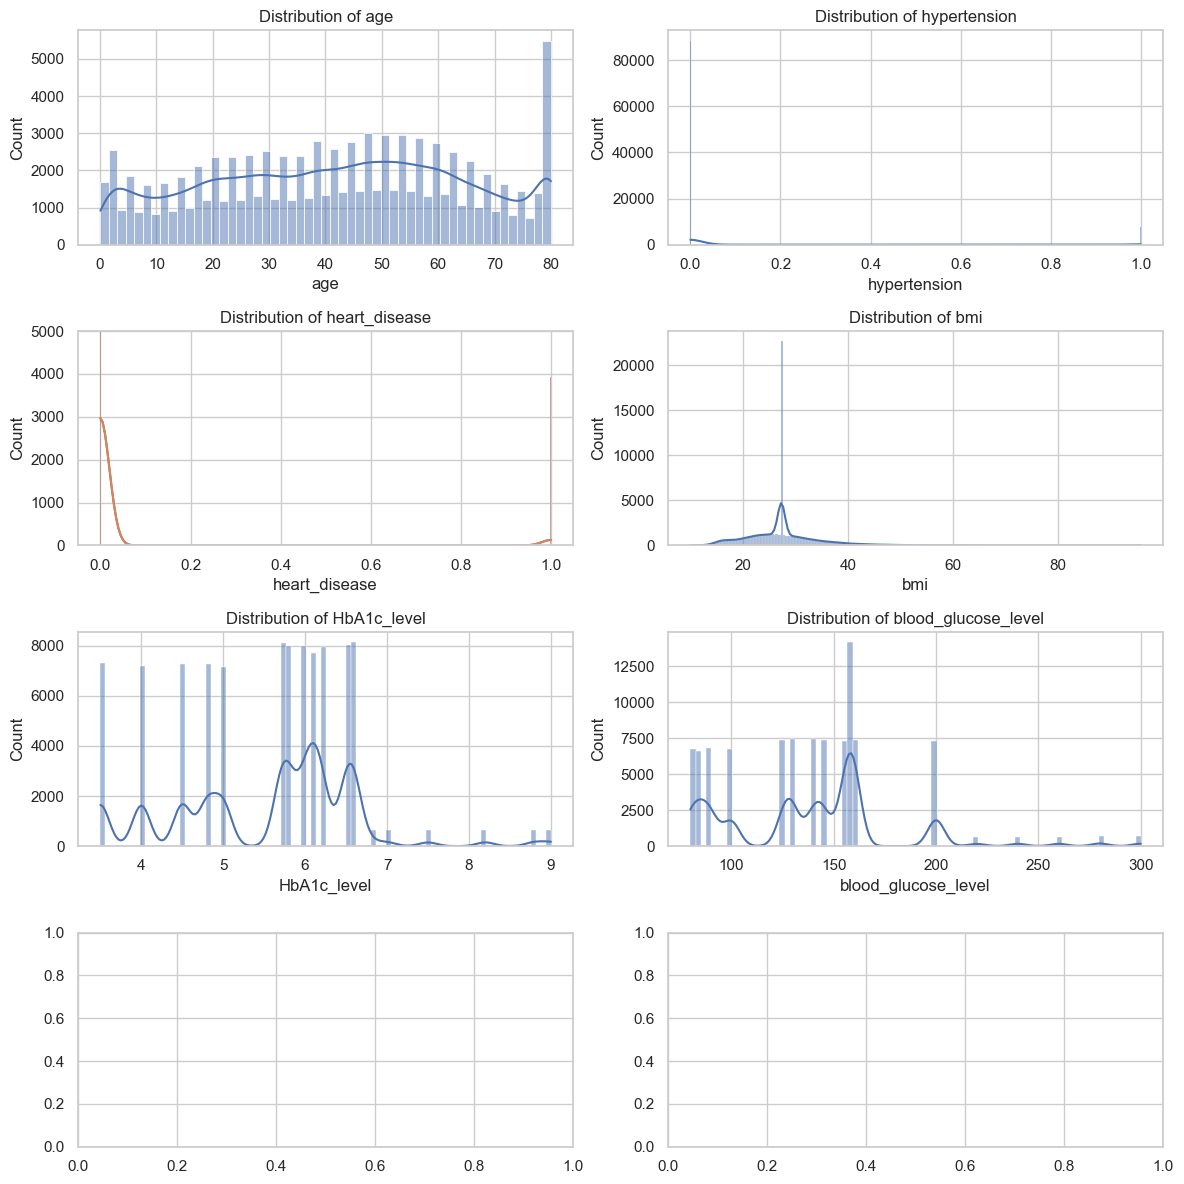

In [291]:
# don't include diabetes for now
numerical_cols_to_plot = numerical_cols.drop(['diabetes'])

fig, axes = plt.subplots(4, 2, figsize=(12, 12))
for ax, col in zip(axes.flatten(), numerical_cols_to_plot):

    ## skip these columns
    if col in ["Is_Smoker"]:
        continue
    sns.histplot(data=df, x=col,ax=ax, kde=True) 

    # set max height for heart disease
    if col in ['heart_disease']:
        sns.histplot(data=df, x=col,ax=ax, kde=True).set(ylim=(0, 5000))
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

Programmatically check for skewness in numerical columns

In [292]:
for col in non_numerical_cols:
    print("Skewness of", col, ":", df[col].value_counts().skew())
 
    # interpretation 
    if df[col].value_counts().skew() > 1:
        print("The distribution of", col, "is highly skewed.")
    elif df[col].value_counts().skew() > 0.5:
        print("The distribution of", col, "is moderately skewed.")
    elif df[col].value_counts().skew() > -0.5:
        print("The distribution of", col, "is approximately symmetric.")
    elif df[col].value_counts().skew() > -1:
        print("The distribution of", col, "is moderately skewed (negative).")
    else:
        print("The distribution of", col, "is highly skewed (negative).")
    print("\n")
    
for col in numerical_cols:
    print("Skewness of", col, ":", df[col].skew())
    
    # interpretation
    if df[col].skew() > 1:
        print("The distribution of", col, "is highly skewed.")
    elif df[col].skew() > 0.5:
        print("The distribution of", col, "is moderately skewed.")
    elif df[col].skew() > -0.5:
        print("The distribution of", col, "is approximately symmetric.")
    elif df[col].skew() > -1:
        print("The distribution of", col, "is moderately skewed (negative).")
    else:
        print("The distribution of", col, "is highly skewed (negative).")
    print("\n")

Skewness of gender : -1.14245114904853
The distribution of gender is highly skewed (negative).


Skewness of smoking_history : -0.5894881364889462
The distribution of smoking_history is moderately skewed (negative).


Skewness of age : -0.06220364949722827
The distribution of age is approximately symmetric.


Skewness of hypertension : 3.1547370339523413
The distribution of hypertension is highly skewed.


Skewness of heart_disease : 4.638820907805003
The distribution of heart_disease is highly skewed.


Skewness of bmi : 1.0228018948003708
The distribution of bmi is highly skewed.


Skewness of HbA1c_level : -0.0543352976607336
The distribution of HbA1c_level is approximately symmetric.


Skewness of blood_glucose_level : 0.8370920691741721
The distribution of blood_glucose_level is moderately skewed.


Skewness of diabetes : 2.9004913109498993
The distribution of diabetes is highly skewed.




### Visualize the Correlation Matrix

In [293]:
numerical_cols_w_target = numerical_cols.tolist() + ['diabetes']
numerical_cols_w_target

['age',
 'hypertension',
 'heart_disease',
 'bmi',
 'HbA1c_level',
 'blood_glucose_level',
 'diabetes',
 'diabetes']

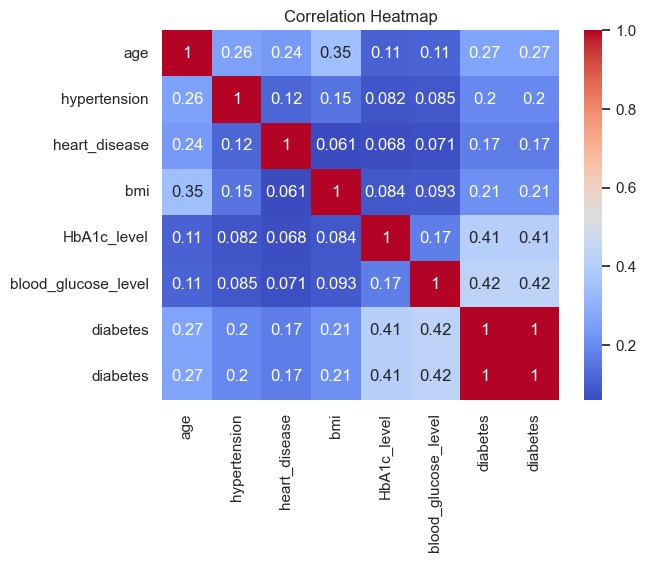

In [294]:
sns.heatmap(df[numerical_cols_w_target].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 5. Removing the outliers

We can use the IQR method to remove outliers from the numerical columns in the dataset. The IQR method is a statistical technique that identifies outliers based on the interquartile range (IQR) of the data. Here's how we can implement this in Python using pandas:

In [295]:
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    clean_data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return clean_data


In [296]:
def show_bounds(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print("lower bound", lower_bound)
    print("upper bound", upper_bound)   

Diabetes and Age (0.27) negligible correlation

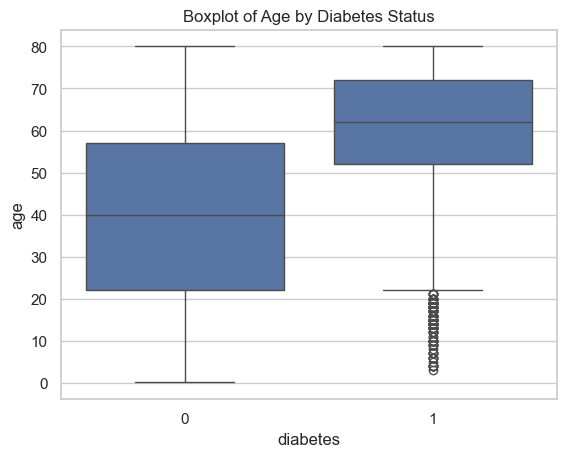

Shows that older people have higher chances of diabetes, but outliers are present.


In [297]:
sns.boxplot(x='diabetes', y='age', data=df)
plt.title('Boxplot of Age by Diabetes Status')
plt.show()
print("Shows that older people have higher chances of diabetes, but outliers are present.")

Diabetes and BMI(0.21)negligible correlation

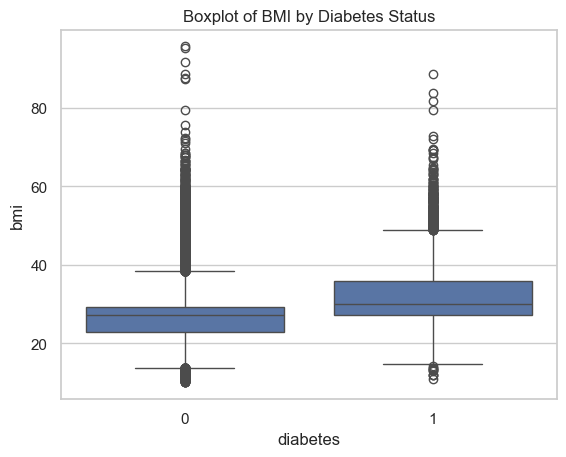

Shows that higher BMI is associated with diabetes, but outliers are present.


In [298]:
sns.boxplot(data=df, x='diabetes', y='bmi')
plt.title('Boxplot of BMI by Diabetes Status')
plt.show()
print("Shows that higher BMI is associated with diabetes, but outliers are present.")

Diabetes and HbA1c(0.41) Low Positive Correlation

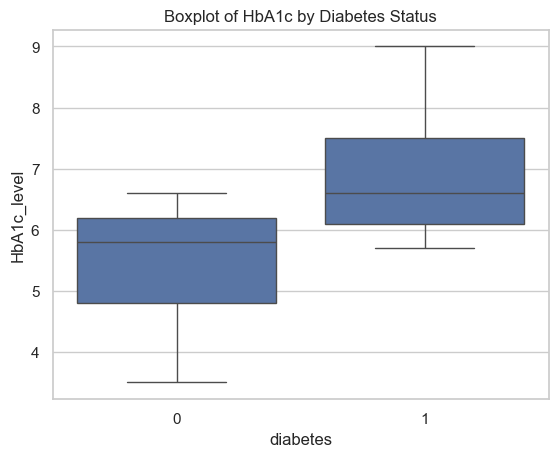

Shows that higher HbA1c levels are associated with diabetes. No significant outliers observed.


In [299]:
sns.boxplot(x='diabetes', y='HbA1c_level', data=df)
plt.title('Boxplot of HbA1c by Diabetes Status')
plt.show()
print("Shows that higher HbA1c levels are associated with diabetes. No significant outliers observed.")

Diabetes and Glucose Level(0.42) Low Positive Correlation

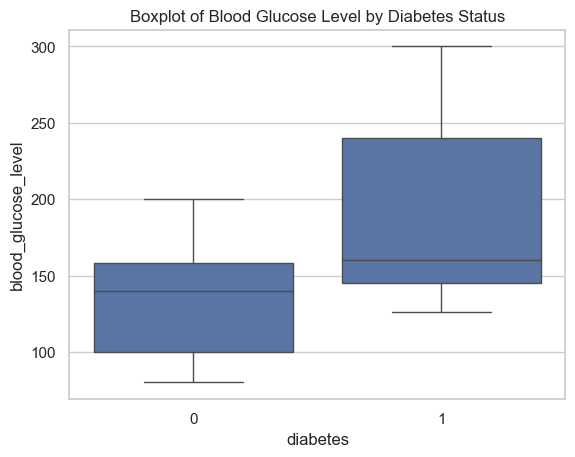

Shows that higher blood glucose levels are associated with diabetes. No significant outliers observed.


In [300]:
sns.boxplot(data=df, x='diabetes', y='blood_glucose_level')
plt.title('Boxplot of Blood Glucose Level by Diabetes Status')
plt.show()
print("Shows that higher blood glucose levels are associated with diabetes. No significant outliers observed.")

## 6. Removing Outliers, doing Corrections, and Flagging Outliers

This will help in improving the model performance.

Questionable data was found in this data set, but instead of cleaning them up, we will flag them as outliers. This will help us retain more data for training the model while still addressing the potential issues with the data.

Check Data for Invalid Outliers on Age

In [301]:
df[(df['age'] <= 20)].min()


gender                  Female
age                       0.08
hypertension                 0
heart_disease                0
smoking_history        Current
bmi                      10.01
HbA1c_level                3.5
blood_glucose_level         80
diabetes                     0
dtype: object

In [302]:
show_bounds(df, 'age')

lower bound -28.5
upper bound 111.5


To minimize the loss of data,  flag improbable ages

In [303]:
df = remove_outliers(df, 'age')
df['age_flagged'] = df['age'].apply(lambda x: 1 if x < 5 or x != int(x) else 0)
df = df[df['age'] >= 1]

Check Data for Invalid Outliers on BMI

In [304]:
df[df['bmi'] > 40].max()

gender                    Male
age                       80.0
hypertension                 1
heart_disease                1
smoking_history        Unknown
bmi                      95.69
HbA1c_level                9.0
blood_glucose_level        300
diabetes                     1
age_flagged                  1
dtype: object

In [305]:
df[df['bmi'] > 20].min()

gender                  Female
age                        1.0
hypertension                 0
heart_disease                0
smoking_history        Current
bmi                      20.01
HbA1c_level                3.5
blood_glucose_level         80
diabetes                     0
age_flagged                  0
dtype: object

In [306]:
show_bounds(df, 'bmi')

lower bound 13.939999999999996
upper bound 39.540000000000006


In [307]:
df = remove_outliers(df, 'bmi')

Dealing with weird data on Smoking History

<small>This assumes that kids that are less than 8 might not be currently seeking out smoking, you must flag this data </small>

In [308]:
df.loc[(df['age'] < 5) & (df['smoking_history'] == "Current"), 'smoking_history'] = "Unknown"

In [309]:
df[df['age'] <= 5][['age', 'smoking_history']]

,age,smoking_history
21,5.00,Unknown
24,4.00,Unknown
35,5.00,Unknown
41,5.00,Unknown
49,3.00,Unknown
...,...,...
99882,3.00,Unknown
99906,3.00,Unknown
99916,1.48,Unknown
99940,2.00,Unknown


## 7. Feature Engineering

This will be used for preproccessing.

Take into Account that although Age and BMI might not be correlated on their own and we need to add feature interactions between them in order to see their significance in diabeters, for example, younger people wth diabetes are outliers but we need to check their glucose_level and their hb1Ac

In [ ]:
# Risk Score (composite feature)

"""
Basis for Risk Score:

Age
- 35 - 44 years old: + 2 points
- 45 - 54 years: +4 points
- 55 - 64 years: +6 points
- 65+: +8 points

BMI:
- Overweight (25-30): +2 points
- Over 30 (Obese): +5 point

Blood Glucose Level:
- 100 - 125 mg/dL (Prediabetes): +3 points

Hemoglobin A1c:
- 5.7% - 6.4% (Prediabetes): +10 points

Hypertension: +2 points
Smoking Group (Engineered Feature):
- current: +2 points
- former: +1 points
- never: 0 points

64 years: +8 points

Male: + 1 points
"""
df_encoded['Risk_Score'] = (df_encoded['hypertension'] * 2 + 
                    df_encoded['heart_disease'] * 3 + 
                    ((df_encoded['bmi'] > 30).astype(int) * 5 + 
                     ((df_encoded['bmi'] > 25) & (df_encoded['bmi'] <= 30)).astype(int) * 2) +
                    ((df_encoded['blood_glucose_level'] >= 100) & (df_encoded['blood_glucose_level'] <= 125)).astype(int) * 3 +
                    ((df_encoded['HbA1c_level'] >= 5.7) & (df_encoded['HbA1c_level'] <= 6.4)).astype(int) * 10 +
                    (2 * df_encoded['smoking_history_Current'] +
                     1 * df_encoded['smoking_history_Past'] +
                     0 * df_encoded['smoking_history_Never'] +
                     0 * df_encoded['smoking_history_Unknown']))

Breaking down Glucose and Hb1AC

In [311]:
median_hbA1c = df['HbA1c_level'].median()
median_gluc_level = df['blood_glucose_level'].median()

print("Median Glucose Level: ", median_gluc_level)
print("Median Hb1AC Level: ", median_hbA1c)

df_feat = df.copy()
df_feat['elevated_glucose'] = df_feat.apply(lambda x: 1 if x['blood_glucose_level'] > median_gluc_level else 0, axis=1)
df_feat['elevated_hbA1c'] = df_feat.apply(lambda x: 1 if x['HbA1c_level'] > median_hbA1c else 0, axis=1)

df_feat[df_feat['age'] <=20][['age', 'elevated_glucose', 'elevated_hbA1c']]
df_feat.head()

Median Glucose Level:  140.0
Median Hb1AC Level:  5.8


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,age_flagged,Risk_Score,elevated_glucose,elevated_hbA1c
0,Female,80.0,0,1,Never,25.19,6.6,140,0,0,3,0,1
1,Female,54.0,0,0,Unknown,27.32,6.6,80,0,0,0,0,1
2,Male,28.0,0,0,Never,27.32,5.7,158,0,0,1,1,0
3,Female,36.0,0,0,Current,23.45,5.0,155,0,0,1,1,0
4,Male,76.0,1,1,Current,20.14,4.8,155,0,0,6,1,0


Data shows high blood glucose levels and HBA1c even if the age is low, when young people with diabetes

### Breaking down age based on seniority

One can use the OrdinalEncoder of Sklearn to convert the values, underweight, normal, and overweight to 0,1,2 but to make things already numberical use an apply to set those values

In [312]:

child = 12 # define age threshold for children
teenager = 13 # define age threshold for teenagers
adult = 20 # define age threshold for adults
senior =60 # define age threshold for seniors

# apply ordinal encoding based on age groups

df['Age_Group'] = df['age'].apply(lambda x: 0 if x <= child else 1 if x <= teenager else 2 if x <= adult else 3 if x < senior else 4)


### Breaking down age based on weight

In [313]:
df_feat[df_feat['bmi'] <20].min()

gender                  Female
age                        1.0
hypertension                 0
heart_disease                0
smoking_history        Current
bmi                      13.94
HbA1c_level                3.5
blood_glucose_level         80
diabetes                     0
age_flagged                  0
Risk_Score                   0
elevated_glucose             0
elevated_hbA1c               0
dtype: object

In [314]:
median_bmi = df['bmi'].median()
print("Median BMI: ", median_bmi)

Median BMI:  27.32


In [315]:
df_feat['weight_class'] = df_feat.apply(lambda x: 2 if x['bmi'] > median_bmi else 0 if x['bmi'] < median_bmi else 1, axis=1)
df_feat[(df_feat['diabetes'] == 1) & ((df_feat['bmi'] < median_bmi) | (df_feat['bmi'] > median_bmi)) ][['age', 'bmi','weight_class', 'diabetes']]

,age,bmi,weight_class,diabetes
6,44.0,19.31,0,1
40,73.0,25.91,0,1
55,50.0,37.16,2,1
87,36.0,32.27,2,1
125,77.0,31.70,2,1
...,...,...,...,...
99935,65.0,33.55,2,1
99938,55.0,30.42,2,1
99957,61.0,34.45,2,1
99962,58.0,38.31,2,1


In [316]:
df_feat.groupby('weight_class')['diabetes'].sum()

weight_class
0    1669
1    1513
2    4029
Name: diabetes, dtype: int64

In [317]:
df_feat

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,age_flagged,Risk_Score,elevated_glucose,elevated_hbA1c,weight_class
0,Female,80.0,0,1,Never,25.19,6.6,140,0,0,3,0,1,0
1,Female,54.0,0,0,Unknown,27.32,6.6,80,0,0,0,0,1,1
2,Male,28.0,0,0,Never,27.32,5.7,158,0,0,1,1,0,1
3,Female,36.0,0,0,Current,23.45,5.0,155,0,0,1,1,0,0
4,Male,76.0,1,1,Current,20.14,4.8,155,0,0,6,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,Female,36.0,0,0,Unknown,24.60,4.8,145,0,0,1,1,0,0
99996,Female,2.0,0,0,Unknown,17.37,6.5,100,0,1,0,0,1,0
99997,Male,66.0,0,0,Past,27.83,5.7,155,0,0,1,1,0,2
99998,Female,24.0,0,0,Never,35.42,4.0,100,0,0,1,0,0,2


In [318]:
print(df_feat.shape)
print(df_feat.info())

(89732, 14)
<class 'pandas.core.frame.DataFrame'>
Index: 89732 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               89732 non-null  object 
 1   age                  89732 non-null  float64
 2   hypertension         89732 non-null  int64  
 3   heart_disease        89732 non-null  int64  
 4   smoking_history      89732 non-null  object 
 5   bmi                  89732 non-null  float64
 6   HbA1c_level          89732 non-null  float64
 7   blood_glucose_level  89732 non-null  int64  
 8   diabetes             89732 non-null  int64  
 9   age_flagged          89732 non-null  int64  
 10  Risk_Score           89732 non-null  int64  
 11  elevated_glucose     89732 non-null  int64  
 12  elevated_hbA1c       89732 non-null  int64  
 13  weight_class         89732 non-null  int64  
dtypes: float64(3), int64(9), object(2)
memory usage: 10.3+ MB
None


## 8. Prerpocessing

### Encoding

Right now we have 2 categorical columns, One can be encoded binary (Gender) and the other is to use the oneHot to prevent ranking. 

In [319]:
categorical_cols = df_feat.select_dtypes(include=['object']).columns
categorical_cols

Index(['gender', 'smoking_history'], dtype='object')

In [320]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

In [321]:
le = LabelEncoder()


df_feat['gender'] = le.fit_transform(df_feat['gender'])


In [322]:
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,age_flagged,Risk_Score,Age_Group
0,Female,80.0,0,1,Never,25.19,6.6,140,0,0,3,4
1,Female,54.0,0,0,Unknown,27.32,6.6,80,0,0,0,3
2,Male,28.0,0,0,Never,27.32,5.7,158,0,0,1,3
3,Female,36.0,0,0,Current,23.45,5.0,155,0,0,1,3
4,Male,76.0,1,1,Current,20.14,4.8,155,0,0,6,4
...,...,...,...,...,...,...,...,...,...,...,...,...
99994,Female,36.0,0,0,Unknown,24.60,4.8,145,0,0,1,3
99996,Female,2.0,0,0,Unknown,17.37,6.5,100,0,1,0,0
99997,Male,66.0,0,0,Past,27.83,5.7,155,0,0,1,4
99998,Female,24.0,0,0,Never,35.42,4.0,100,0,0,1,3


In [323]:
oe = OneHotEncoder(sparse_output=False,)

transformed_cols = oe.fit_transform(df_feat[['smoking_history']])
transformed_col_names = oe.get_feature_names_out(['smoking_history'])
df_transformed = pd.DataFrame(transformed_cols, columns=transformed_col_names)


# create encoded dataframe
df_encoded = pd.concat([df_feat.reset_index(drop=True).drop(['smoking_history'], axis=1), df_transformed.reset_index(drop=True)], axis=1)


# Recalculate Risk Score on encoded dataframe
df_encoded['Risk_Score'] = (df_encoded['hypertension'] * 2 + 
                    df_encoded['heart_disease'] * 3 + 
                    ((df_encoded['bmi'] > 30).astype(int) * 5 + 
                     ((df_encoded['bmi'] > 25) & (df_encoded['bmi'] <= 30)).astype(int) * 2) +
                    ((df_encoded['blood_glucose_level'] >= 100) & (df_encoded['blood_glucose_level'] <= 125)).astype(int) * 3 +
                    ((df_encoded['HbA1c_level'] >= 5.7) & (df_encoded['HbA1c_level'] <= 6.4)).astype(int) * 10 +
                    (2 * df_encoded['smoking_history_Current'] +
                     1 * df_encoded['smoking_history_Past'] +
                     0 * df_encoded['smoking_history_Never'] +
                     0 * df_encoded['smoking_history_Unknown']))
df_encoded.head(40)

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,age_flagged,Risk_Score,elevated_glucose,elevated_hbA1c,weight_class,smoking_history_Current,smoking_history_Never,smoking_history_Past,smoking_history_Unknown
0,0,80.0,0,1,25.19,6.6,140,0,0,5.0,0,1,0,0.0,1.0,0.0,0.0
1,0,54.0,0,0,27.32,6.6,80,0,0,2.0,0,1,1,0.0,0.0,0.0,1.0
2,1,28.0,0,0,27.32,5.7,158,0,0,12.0,1,0,1,0.0,1.0,0.0,0.0
3,0,36.0,0,0,23.45,5.0,155,0,0,2.0,1,0,0,1.0,0.0,0.0,0.0
4,1,76.0,1,1,20.14,4.8,155,0,0,7.0,1,0,0,1.0,0.0,0.0,0.0
5,0,20.0,0,0,27.32,6.6,85,0,0,2.0,0,1,1,0.0,1.0,0.0,0.0
6,0,44.0,0,0,19.31,6.5,200,1,0,0.0,1,1,0,0.0,1.0,0.0,0.0
7,0,79.0,0,0,23.86,5.7,85,0,0,10.0,0,0,0,0.0,0.0,0.0,1.0
8,1,42.0,0,0,33.64,4.8,145,0,0,5.0,1,0,2,0.0,1.0,0.0,0.0
9,0,32.0,0,0,27.32,5.0,100,0,0,5.0,0,0,1,0.0,1.0,0.0,0.0


In [324]:
df.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
age_flagged            0
Risk_Score             0
Age_Group              0
dtype: int64

### SMOTE and SPLITTING

<Axes: xlabel='diabetes', ylabel='count'>

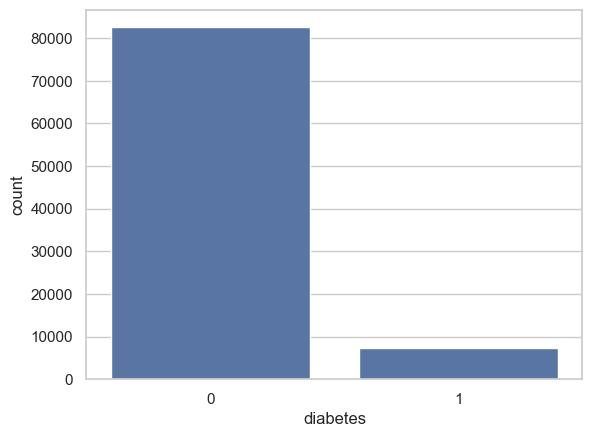

In [325]:
sns.countplot(data=df_encoded, x='diabetes')

There's a clear imbalance in the sampling of the target variable 'diabetes', with a significantly higher number of non-diabetic cases compared to diabetic cases. This class imbalance could potentially impact the performance of machine learning models trained on this data, as they may become biased towards the majority class.

In [326]:
df_encoded.isna().sum()

gender                     0
age                        0
hypertension               0
heart_disease              0
bmi                        0
HbA1c_level                0
blood_glucose_level        0
diabetes                   0
age_flagged                0
Risk_Score                 0
elevated_glucose           0
elevated_hbA1c             0
weight_class               0
smoking_history_Current    0
smoking_history_Never      0
smoking_history_Past       0
smoking_history_Unknown    0
dtype: int64

### Splitting Data

In [327]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.


In [328]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [329]:
# features
X = df_encoded.drop('diabetes', axis=1)
#target
y = df_encoded['diabetes']

# Stratified split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


# Apply SMOTE only to training set
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


<Axes: xlabel='diabetes', ylabel='count'>

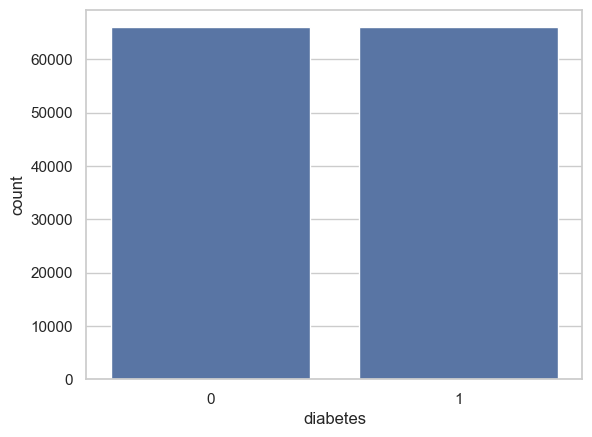

In [330]:
sns.countplot(x=y_train_smote)

### Scaling Data

In [331]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [332]:
print("Old Scale: ")
print(np.min(X_train_smote)," <-> " ,np.max(X_train_smote))

Old Scale: 
0.0  <->  300.0


In [333]:
# scale only the features (this helps with convergence for some models)
X_train_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

After Scaling Data:

In [334]:
print("New Scale:")
print(np.min(X_train_scaled)," <-> " ,np.max(X_train_scaled))

New Scale:
-2.7488382680957075  <->  6.264294838222159


### Classifiers

In [335]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#### Logistic Regression

In [336]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train_smote)

y_pred_log = log_reg.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9075054326628406

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.92      0.95     16505
           1       0.46      0.79      0.58      1442

    accuracy                           0.91     17947
   macro avg       0.72      0.85      0.76     17947
weighted avg       0.94      0.91      0.92     17947



#### K-Nearest Neighbors

In [337]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train_smote)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.9305733548782527

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96     16505
           1       0.55      0.70      0.62      1442

    accuracy                           0.93     17947
   macro avg       0.76      0.82      0.79     17947
weighted avg       0.94      0.93      0.93     17947



#### Support Vector Machine (SVM)

In [338]:
from sklearn.svm import SVC

# Initialize and Train (Using RBF kernel for non-linearity)
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train_smote)

y_pred_svm = svm.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9417729982726918

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97     16505
           1       0.62      0.73      0.67      1442

    accuracy                           0.94     17947
   macro avg       0.80      0.85      0.82     17947
weighted avg       0.95      0.94      0.94     17947



#### Decision Trees

In [339]:
from sklearn.tree import DecisionTreeClassifier


# Note: We use unscaled data because decision trees don't require scaling
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_smote, y_train_smote)

# Predict
y_pred_dt = dt.predict(X_test)

# Evaluate
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9520811277650861

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97     16505
           1       0.70      0.71      0.70      1442

    accuracy                           0.95     17947
   macro avg       0.84      0.84      0.84     17947
weighted avg       0.95      0.95      0.95     17947



#### Random Forest

In [340]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9652866774391263

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98     16505
           1       0.87      0.67      0.76      1442

    accuracy                           0.97     17947
   macro avg       0.92      0.83      0.87     17947
weighted avg       0.96      0.97      0.96     17947



#### Naive Bayes

In [341]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_smote, y_train_smote)

y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.6734273137571739

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.65      0.78     16505
           1       0.19      0.96      0.32      1442

    accuracy                           0.67     17947
   macro avg       0.59      0.81      0.55     17947
weighted avg       0.93      0.67      0.75     17947



Results

/var/folders/pc/qpl83vwd53v_hm0hj90d3nz00000gn/T/ipykernel_50848/817703230.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')


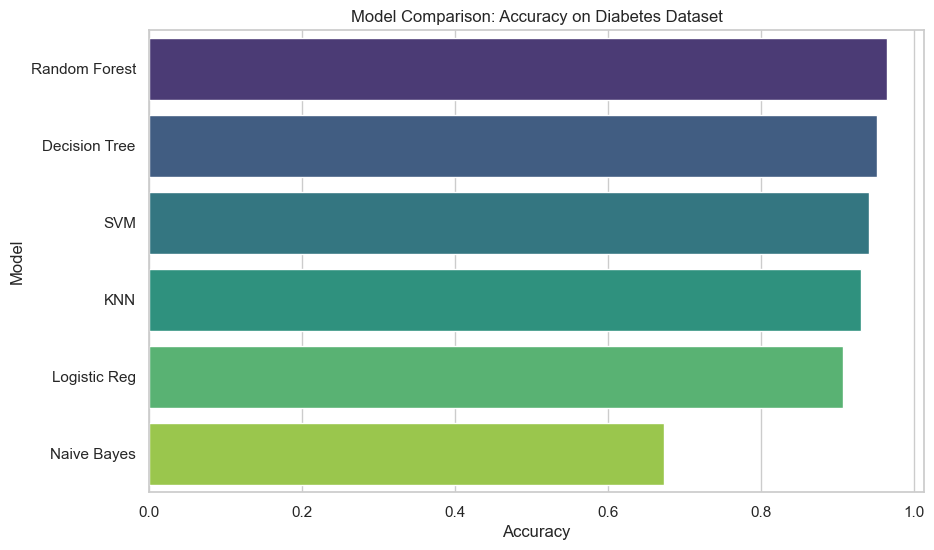

In [342]:
models = ['Logistic Reg', 'KNN', 'SVM', 'Decision Tree', 'Random Forest', 'Naive Bayes']
accuracies = [
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_nb)
]

results_df = pd.DataFrame({'Model': models, 'Accuracy': accuracies})
results_df = results_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
plt.title('Model Comparison: Accuracy on Diabetes Dataset')
plt.xlabel('Accuracy')
plt.show()